#########    All "our" in the following code refers to Joint Cabernet.

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import anndata as ad
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy.stats import gaussian_kde

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = './'
outdir = './'

In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = "/arial/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()

In [ ]:
RNA_origin="Joint_Cabernet"

# get the RNA by sublass df
subclass_list = pd.read_csv('../../../03.data/04.config_files/subclass_order.csv', header=None)[0].to_list()
subclass_list=[i for i in subclass_list if "NN" not in i]

df_RNA=pd.read_csv('../../03.Joint-Cabernet.cellType_State/04-Correlation_calculation/all_cell_correlation/02-our_subclass_mean_dat_final.csv',index_col=0).T.loc[subclass_list,:]
max_threshold_=0.2
cv_threshold_=0.4
df_RNA_selected=df_RNA.loc[subclass_list,:]
df_RNA_selected=df_RNA_selected.loc[subclass_list,
    (df_RNA_selected.max(axis=0)>max_threshold_) &
    (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)
            ]

/tmp/ipykernel_18735/2703861518.py:13: RuntimeWarning: invalid value encountered in scalar divide
  (df_RNA_selected.apply(lambda col: col.std() / col.mean(), axis=0)>cv_threshold_)


In [5]:
df_RNA_selected

,ENSMUSG00000002459.17,ENSMUSG00000025905.13,ENSMUSG00000033740.17,ENSMUSG00000067879.3,ENSMUSG00000025915.14,ENSMUSG00000042501.12,ENSMUSG00000048960.13,ENSMUSG00000057715.13,ENSMUSG00000016918.15,ENSMUSG00000025938.16,...,ENSMUSG00000063434.5,ENSMUSG00000043531.16,ENSMUSG00000097636.7,ENSMUSG00000043639.14,ENSMUSG00000024981.6,ENSMUSG00000025085.16,ENSMUSG00000025089.15,ENSMUSG00000025092.6,ENSMUSG00000087095.2,ENSMUSG00000003228.8
L2/3 IT CTX Glut,0.514728,0.002892,0.044854,0.226865,0.401239,0.039873,0.077100,0.746375,0.093341,0.031954,...,1.731531,1.077693,0.006462,0.138960,0.139792,1.503690,0.040495,0.342812,0.077009,0.138162
L4/5 IT CTX Glut,0.234368,0.005700,0.045252,0.218639,0.231069,0.042969,0.067703,0.922805,0.028767,0.048081,...,0.819922,1.973580,0.003496,0.082188,0.196263,1.311148,0.058563,0.332559,0.023379,0.124285
L5 IT CTX Glut,0.301417,0.074027,0.050697,0.476340,0.240433,0.087553,0.086541,1.235155,0.215684,0.037116,...,1.953426,1.319674,0.003935,0.050022,0.157297,1.417625,0.066063,0.270491,0.011314,0.197072
L6 IT CTX Glut,0.250545,0.119963,0.036756,0.406675,0.276309,0.057813,0.131841,1.587347,0.747573,0.030990,...,1.860657,1.332079,0.011670,0.066528,0.147294,1.223675,0.040806,0.212130,0.004678,0.234160
IT AON-TT-DP Glut,0.324420,0.014120,0.034911,0.168316,0.298051,0.068886,0.192879,1.477304,0.240858,0.088805,...,1.065682,0.936945,0.007152,0.147187,0.126288,1.267522,0.053956,0.405244,0.072030,0.176216
LA-BLA-BMA-PA Glut,0.315862,0.002466,0.017635,0.000339,0.204269,0.156419,0.206263,1.475192,0.086062,0.057432,...,0.624720,1.433874,0.000000,0.015076,0.117470,1.282097,0.058372,0.229635,0.000287,0.298981
L2/3 IT RSP Glut,0.251099,0.007903,0.052549,0.194189,0.198190,0.119498,0.077849,0.711263,0.039551,0.040545,...,1.070824,1.447553,0.008792,0.098434,0.191200,1.118973,0.044370,0.313964,0.013851,0.105733
L4 RSP-ACA Glut,0.115259,0.002343,0.037028,0.169607,0.256681,0.722258,0.132767,1.085559,0.059817,0.072089,...,1.474571,0.592114,0.006005,0.086578,0.208496,0.988793,0.028799,0.407764,0.018907,0.116138
L5 ET CTX Glut,0.366215,0.006171,0.053892,0.378033,0.325558,0.069857,0.203598,1.582146,0.036809,0.056024,...,0.572815,2.305443,0.028576,0.082455,0.152500,0.847292,0.031017,0.456840,0.005023,0.140302
SUB-ProS Glut,0.307113,0.001455,0.129194,0.314935,0.222461,0.031959,0.232066,0.928539,0.022017,0.024764,...,0.500580,1.061090,0.242622,0.027029,0.111649,0.265203,0.885735,0.417370,0.072196,0.084257


In [ ]:
state="hyper"

df_frac_segment_subclass=dict()
df_frac_segment_subclass["5hmCG"]=ad.read_h5ad('5hmC_merged_allc_with_5hmC_segment.h5ad').to_df().iloc[:len(subclass_list),:]
df_frac_segment_subclass["5hmCG"].index=df_RNA.index

DMR_states_df=ad.read_h5ad('../../04.subclass.DMR/03-stratified_RankSumTest_1vsOthers/01_subclasses_in_neuron_1vsOthers/5hmCG_DMR_states_neuron_1vsOthers.h5ad').to_df()

if state == "hyper":
    segment_differential_states=(DMR_states_df==1).sum(axis=0)
elif state == "hypo":
    segment_differential_states=(DMR_states_df==-1).sum(axis=0)
elif state == "all":
    segment_differential_states=(DMR_states_df.abs()==1).sum(axis=0)

differential_segments=segment_differential_states[segment_differential_states>0].index


In [7]:
differential_segments

Index(['chr1_3006415_3007171', 'chr1_3019020_3019545', 'chr1_3023074_3023890',
       'chr1_3035700_3035928', 'chr1_3050023_3051133', 'chr1_3074366_3074990',
       'chr1_3076706_3077471', 'chr1_3084207_3084772', 'chr1_3096675_3097965',
       'chr1_3098659_3098992',
       ...
       'chr19_61118943_61119296', 'chr19_61193790_61194246',
       'chr19_61201861_61202400', 'chr19_61203588_61203873',
       'chr19_61204677_61205162', 'chr19_61238016_61238441',
       'chr19_61275626_61277411', 'chr19_61286843_61287489',
       'chr19_61288301_61288928', 'chr19_61313965_61314559'],
      dtype='object', name='segment', length=153580)

In [8]:
loops_df = pd.read_csv(f'{indir}/intergenic_to_selectedGenes_dots_withPCC_3C_RNA.tsv', sep="\t")

In [9]:
loops_df

,chrom1,start1,end1,chrom2,start2,end2,bin1,bin2,kernel_id,iteration,score,pvalue,qvalue,subclass,bin1_intergenic,bin1_selected,bin2_intergenic,bin2_selected,bin_status,PCC_3C_RNA
0,chr1,3050000,3060000,chr1,5040000,5050000,305,504,0,0,0.482867,1.000000e-10,1.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001,"[(305, 504, 'chr1', 305, 'ENSMUSG00000002459.1..."
1,chr1,3110000,3120000,chr1,6740000,6750000,311,674,0,0,0.363741,6.510000e-08,6.850000e-08,L2/3 IT CTX Glut,True,False,False,True,1001,"[(311, 674, 'chr1', 311, 'ENSMUSG00000033740.1..."
2,chr1,3110000,3120000,chr1,6790000,6800000,311,679,0,0,0.417278,3.000000e-10,4.000000e-10,L2/3 IT CTX Glut,True,False,False,True,1001,"[(311, 679, 'chr1', 311, 'ENSMUSG00000033740.1..."
3,chr1,3690000,3700000,chr1,6520000,6530000,369,652,0,0,0.316687,2.920000e-08,3.150000e-08,L2/3 IT CTX Glut,True,False,False,True,1001,"[(369, 652, 'chr1', 369, 'ENSMUSG00000033740.1..."
4,chr1,3730000,3740000,chr1,6680000,6690000,373,668,0,0,0.483908,0.000000e+00,0.000000e+00,L2/3 IT CTX Glut,True,False,False,True,1001,"[(373, 668, 'chr1', 373, 'ENSMUSG00000033740.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143935,chr19,59760000,59770000,chr19,60950000,60960000,246117,246236,0,0,0.431532,8.000000e-10,9.000000e-10,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246117, 246236, 'chr19', 5976, 'ENSMUSG00000..."
1143936,chr19,59840000,59850000,chr19,60950000,60960000,246125,246236,0,0,0.534147,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246125, 246236, 'chr19', 5984, 'ENSMUSG00000..."
1143937,chr19,60090000,60100000,chr19,61010000,61020000,246150,246242,0,0,0.330801,4.860000e-08,5.060000e-08,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246150, 246242, 'chr19', 6009, 'ENSMUSG00000..."
1143938,chr19,60250000,60260000,chr19,60980000,60990000,246166,246239,0,0,0.483798,0.000000e+00,0.000000e+00,ACB-BST-FS D1 Gaba,True,False,False,True,1001,"[(246166, 246239, 'chr19', 6025, 'ENSMUSG00000..."


In [10]:
selected_loops=[]
for i in tqdm(loops_df["PCC_3C_RNA"],  total=len(loops_df["PCC_3C_RNA"])):
    temp=eval(i)
    for j in temp:
        if (np.abs(j[0]-j[1])<=500/10): # require the loop distance to be no more than 500kb
            selected_loops.append(j)
selected_loops_df = pd.DataFrame(selected_loops, 
                             columns=["bin_intergenic", "bin_gene",
                             "chromosome", "bin_intergenic_in_chromosome",
                             "gene_id", "PCC_3C_RNA"])
selected_loops_df['bin_distance'] = (selected_loops_df['bin_intergenic'] - selected_loops_df['bin_gene']).abs()
selected_loops_df=selected_loops_df.drop_duplicates()

  0%|          | 0/1143940 [00:00<?, ?it/s]

In [11]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.173279,41
1,641,685,chr1,641,ENSMUSG00000033740.17,0.160804,44
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.187581,19
3,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.236113,26
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.366329,30
...,...,...,...,...,...,...,...
52958,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.168142,23
52959,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.107573,40
52960,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.171511,33
52962,246028,245978,chr19,5887,ENSMUSG00000025089.15,-0.117808,50


In [ ]:
mm10_chrom_sizes=pd.read_csv('../../../03.data/01.ref/mm10.chrom.sizes.nochrM.txt', sep='\t', header=None, names=['chromosome', 'length'])
mm10_chrom_sizes

,chromosome,length
0,chr1,195471971
1,chr2,182113224
2,chr3,160039680
3,chr4,156508116
4,chr5,151834684
5,chr6,149736546
6,chr7,145441459
7,chr8,129401213
8,chr9,124595110
9,chr10,130694993


In [13]:
resolution_ = 10_000
window_size_ = 30_000

with open(f'{indir}/5hmCG_frac_chrom30k_step10k_by_subclass/sliding_30kb_bins_10kb_step.bed', 'wt') as f:
    for _, row_ in mm10_chrom_sizes.iterrows():
        chrom_, length_ = row_
        print(chrom_, length_)
        bins = int(np.ceil(length_ / resolution_))
        starts = [ i * resolution_ for i in range(bins)]
        ends = [ min(start_ + window_size_, length_) for start_ in starts]
        for start_, end_ in zip(starts, ends):
            f.write(f'{chrom_}\t{start_}\t{end_}\t{chrom_}_{start_}_{end_}\n')

chr1 195471971
chr2 182113224
chr3 160039680
chr4 156508116
chr5 151834684
chr6 149736546
chr7 145441459
chr8 129401213
chr9 124595110
chr10 130694993
chr11 122082543
chr12 120129022
chr13 120421639
chr14 124902244
chr15 104043685
chr16 98207768
chr17 94987271
chr18 90702639
chr19 61431566
chrX 171031299
chrY 91744698


In [14]:
df_chrom30k_step10k = ad.read_h5ad(f'{indir}/5hmCG_frac_chrom30k_step10k_by_subclass/5hmCG_frac_chrom30k_step10k_by_subclass.h5ad').to_df().iloc[:len(subclass_list),]
df_chrom30k_step10k.iloc[:, 1000:1010]

chrom30k_step10k,chr1_10000000_10030000,chr1_10010000_10040000,chr1_10020000_10050000,chr1_10030000_10060000,chr1_10040000_10070000,chr1_10050000_10080000,chr1_10060000_10090000,chr1_10070000_10100000,chr1_10080000_10110000,chr1_10090000_10120000
cell,,,,,,,,,,
5hmC_L2_3_IT_CTX_Glut.Merge.allc,0.247251,0.189687,0.202857,0.210587,0.314015,0.338948,0.331013,0.329810,0.325663,0.320462
5hmC_L4_5_IT_CTX_Glut.Merge.allc,0.251842,0.191007,0.198808,0.200799,0.301314,0.320725,0.320022,0.318587,0.317892,0.319173
5hmC_L5_IT_CTX_Glut.Merge.allc,0.282218,0.216555,0.223676,0.231042,0.327768,0.344848,0.337167,0.343923,0.350531,0.346222
5hmC_L6_IT_CTX_Glut.Merge.allc,0.270499,0.217069,0.225784,0.237105,0.324663,0.345374,0.329930,0.334238,0.343380,0.337602
5hmC_IT_AON-TT-DP_Glut.Merge.allc,0.259325,0.201817,0.218561,0.229656,0.333970,0.352297,0.343486,0.339747,0.358569,0.346576
5hmC_LA-BLA-BMA-PA_Glut.Merge.allc,0.302743,0.236777,0.246875,0.249729,0.340637,0.341168,0.335094,0.336342,0.355651,0.354487
5hmC_L2_3_IT_RSP_Glut.Merge.allc,0.271531,0.208957,0.211944,0.212234,0.316367,0.339542,0.341837,0.345955,0.351321,0.341169
5hmC_L4_RSP-ACA_Glut.Merge.allc,0.306246,0.220927,0.235849,0.241042,0.363803,0.394282,0.395911,0.400330,0.390535,0.372966
5hmC_L5_ET_CTX_Glut.Merge.allc,0.302638,0.217758,0.221850,0.229953,0.341692,0.365975,0.361479,0.375337,0.379691,0.379465


In [15]:
def get_5hmCG_RNA_PCC(row_):
    chrom_, bin_intergenic_in_chromosome_, gene_id_ = row_[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id']]
    DNA_ = df_chrom30k_step10k.loc[:,f'{chrom_}_{10_000*(bin_intergenic_in_chromosome_-1)}_{10_000*(bin_intergenic_in_chromosome_+2)}'] #大概不会有正好在染色体末尾的loops
    RNA_=df_RNA_selected.loc[:, gene_id_]
    RNA_DNA_filterNA=[(r,d) for r, d in zip(RNA_, DNA_) if ~(np.isnan(r) | np.isnan(d))]
    RNA_=[i[0] for i in RNA_DNA_filterNA]
    DNA_=[i[1] for i in RNA_DNA_filterNA]
    coef, p_value = pearsonr(RNA_, DNA_)
    return coef

In [16]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.173279,41
1,641,685,chr1,641,ENSMUSG00000033740.17,0.160804,44
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.187581,19
3,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.236113,26
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.366329,30
...,...,...,...,...,...,...,...
52958,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.168142,23
52959,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.107573,40
52960,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.171511,33
52962,246028,245978,chr19,5887,ENSMUSG00000025089.15,-0.117808,50


In [17]:
selected_loops_df['PCC_5hmCG_RNA']=selected_loops_df.apply(get_5hmCG_RNA_PCC, axis=1)

In [18]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.173279,41,-0.164281
1,641,685,chr1,641,ENSMUSG00000033740.17,0.160804,44,-0.379348
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.187581,19,-0.192958
3,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.236113,26,-0.117262
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.366329,30,-0.012060
...,...,...,...,...,...,...,...,...
52958,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.168142,23,0.495986
52959,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.107573,40,0.064510
52960,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.171511,33,-0.033414
52962,246028,245978,chr19,5887,ENSMUSG00000025089.15,-0.117808,50,-0.016695


In [19]:
differential_segments=pd.Series(differential_segments)
differential_segments

0            chr1_3006415_3007171
1            chr1_3019020_3019545
2            chr1_3023074_3023890
3            chr1_3035700_3035928
4            chr1_3050023_3051133
                   ...           
153575    chr19_61238016_61238441
153576    chr19_61275626_61277411
153577    chr19_61286843_61287489
153578    chr19_61288301_61288928
153579    chr19_61313965_61314559
Name: segment, Length: 153580, dtype: object

In [20]:
differential_segments_by_chrom = {chrom_ : differential_segments[differential_segments.str.startswith(f'{chrom_}_')] for chrom_ in [f'chr{i}' for i in range(1,20)]}

In [21]:
def check_having_hyperDHMR(row_):
    chrom_, bin_intergenic_in_chromosome_ = row_[['chromosome', 'bin_intergenic_in_chromosome']]
    bin_start_ = 10_000*(bin_intergenic_in_chromosome_-1)
    bin_end_ = 10_000*(bin_intergenic_in_chromosome_+2)
    for segment_ in differential_segments_by_chrom[chrom_]:
        _, start_, end_ = segment_.split('_')
        start_, end_ = map(int, (start_, end_))
        if bin_start_ <= start_ < end_ <= bin_end_:
            return True
    return False

In [22]:
np.sum(selected_loops_df.iloc[1000:1100].apply(check_having_hyperDHMR, axis=1))

88

In [23]:
print(datetime.now())
print(selected_loops_df.shape)
selected_loops_df=selected_loops_df[selected_loops_df.apply(check_having_hyperDHMR, axis=1)]
print(datetime.now())
print(selected_loops_df.shape)

2025-11-20 16:40:36.815255
(38526, 8)
2025-11-20 16:42:15.570171
(33098, 8)


In [24]:
selected_loops_df

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
0,463,504,chr1,463,ENSMUSG00000002459.17,-0.173279,41,-0.164281
1,641,685,chr1,641,ENSMUSG00000033740.17,0.160804,44,-0.379348
2,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.187581,19,-0.192958
3,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.236113,26,-0.117262
4,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.366329,30,-0.012060
...,...,...,...,...,...,...,...,...
52957,245231,245186,chr19,5090,ENSMUSG00000043531.16,0.194160,45,0.405914
52958,245228,245205,chr19,5087,ENSMUSG00000043531.16,0.168142,23,0.495986
52959,245483,245523,chr19,5342,ENSMUSG00000043639.14,0.107573,40,0.064510
52960,245482,245515,chr19,5341,ENSMUSG00000043639.14,-0.171511,33,-0.033414


<Axes: >

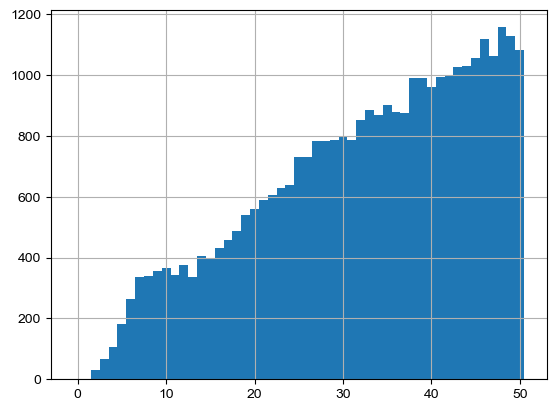

In [25]:
selected_loops_df['bin_distance'].hist(bins=51, range=(-0.5,50.5))

<Axes: >

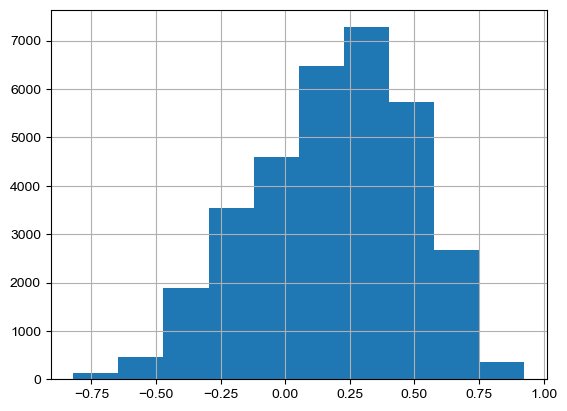

In [26]:
selected_loops_df['PCC_5hmCG_RNA'].hist()

<Axes: >

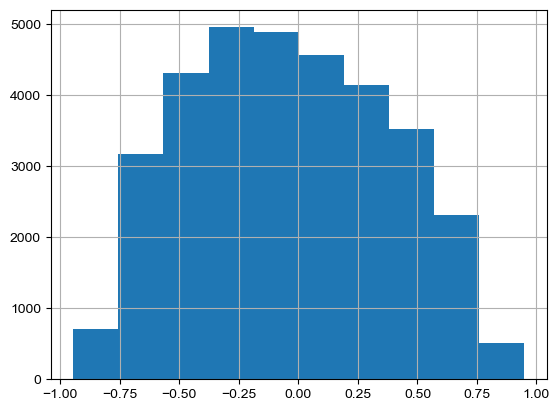

In [27]:
selected_loops_df['PCC_3C_RNA'].hist()

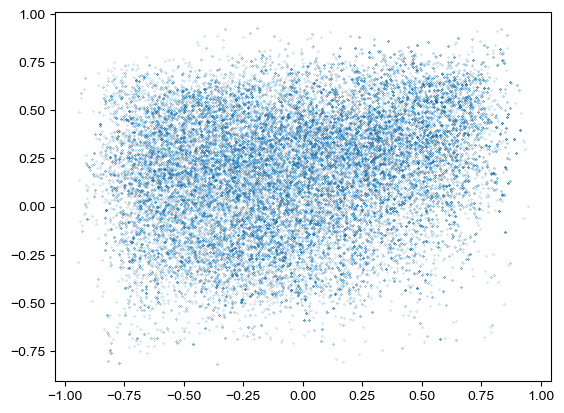

In [28]:
plt.scatter(selected_loops_df['PCC_3C_RNA'], selected_loops_df['PCC_5hmCG_RNA'], marker='.', edgecolors=None, s=0.1)

In [29]:
selected_loops_df[(selected_loops_df['gene_id']=='ENSMUSG00000050830.17') & (selected_loops_df['bin_intergenic_in_chromosome'].apply(lambda x : 1080<= x <=1086))]

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
15022,153669,153704,chr11,1080,ENSMUSG00000050830.17,0.427423,35,0.512560
25109,153670,153715,chr11,1081,ENSMUSG00000050830.17,0.564255,45,0.449479
27223,153671,153709,chr11,1082,ENSMUSG00000050830.17,0.626678,38,0.544396
29050,153671,153700,chr11,1082,ENSMUSG00000050830.17,0.626678,29,0.544396
35812,153672,153700,chr11,1083,ENSMUSG00000050830.17,0.667442,28,0.436526
35813,153671,153711,chr11,1082,ENSMUSG00000050830.17,0.626678,40,0.544396
42787,153674,153712,chr11,1085,ENSMUSG00000050830.17,0.640249,38,0.345081
44596,153672,153701,chr11,1083,ENSMUSG00000050830.17,0.667442,29,0.436526
46342,153672,153711,chr11,1083,ENSMUSG00000050830.17,0.667442,39,0.436526
49890,153674,153709,chr11,1085,ENSMUSG00000050830.17,0.640249,35,0.345081


In [30]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=50)]
x=PCC_df['PCC_3C_RNA'].to_numpy()
y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
x=x[::3]
y=y[::3]
x_and_y=np.vstack([x,y])
print(f'{datetime.now()}\t Started kde')
kde=gaussian_kde(x_and_y)
z=kde(x_and_y)
idx=z.argsort()
x,y,z=x[idx],y[idx],z[idx]
print(f'{datetime.now()}\t kde done')

2025-11-20 16:42:16.087897	 Started kde
2025-11-20 16:42:18.341232	 kde done


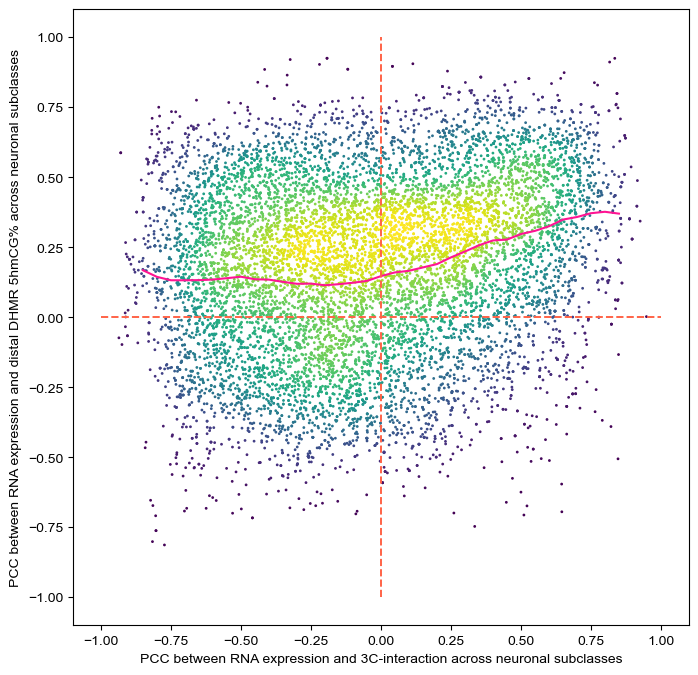

In [31]:
plt.figure(figsize=(8,8))
plt.scatter(x, y ,c=z, marker='.', s=4,edgecolors=None)

plt.xlabel('PCC between RNA expression and 3C-interaction across neuronal subclasses')
plt.ylabel('PCC between RNA expression and distal DHMR 5hmCG% across neuronal subclasses')
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink')

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.show()

In [32]:
selected_loops_df.to_csv('selected_loops.csv', index=False)

In [33]:
from collections import Counter
Counter(PCC_df[['bin_intergenic','bin_gene','chromosome']].value_counts())

Counter({1: 32470, 2: 314})

In [34]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : True)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
print(PCC_df.shape)

(17732, 5)


In [ ]:
from matplotlib.font_manager import fontManager, FontProperties
font_path = "/arial/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['font.size']=5

(17732, 5)
2025-11-20 16:42:19.228292	 Started kde
2025-11-20 16:42:24.997285	 kde done


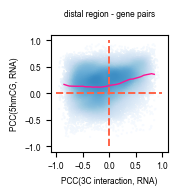

In [36]:
# only showing distal region with hyper DHMR - gene pairs, with the loop distance in the range [20kb, 500kb]
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=50)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
print(PCC_df.shape)

x=PCC_df['PCC_3C_RNA'].to_numpy()
y=PCC_df['PCC_5hmCG_RNA'].to_numpy()
x=x[::1]
y=y[::1]
x_and_y=np.vstack([x,y])
print(f'{datetime.now()}\t Started kde')
kde=gaussian_kde(x_and_y)
z=kde(x_and_y)
idx=z.argsort()
x,y,z=x[idx],y[idx],z[idx]
print(f'{datetime.now()}\t kde done')

cmap_ = 'Blues'
plt.figure(figsize=(45/25.4,50/25.4))
plt.scatter(x, y ,c=z, marker='.', s=1,edgecolors=None, cmap=cmap_,vmin=0,vmax=1.5)

plt.xlabel('PCC(3C interaction, RNA)', fontdict={'size':6})
plt.ylabel('PCC(5hmCG, RNA)', fontdict={'size':6})
plt.gca().set_aspect('equal')
# also drawing the average 5hmCG-RNA_correlation line
average_range=0.05;PCC_3C_RNA_x=np.linspace(-1,1,int(1+2/average_range))[3:-3]
PCC_5hmCG_RNA_per_x=[np.mean(PCC_df[PCC_df['PCC_3C_RNA'].apply(lambda p : x-2*average_range<=p<=x+2*average_range)]['PCC_5hmCG_RNA']) for x in PCC_3C_RNA_x]
plt.plot(PCC_3C_RNA_x, PCC_5hmCG_RNA_per_x, color='deeppink', linewidth=1)

plt.vlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);plt.hlines([0],-1,1, color='tomato', linestyles='dashed', linewidth=1.4);
plt.xticks(size=6)
plt.yticks(size=6)
plt.title(f'distal region - gene pairs\n', size=6)
plt.tight_layout()
plt.savefig(f'{outdir}/PCCscatterplot_all.pdf')
plt.savefig(f'{outdir}/PCCscatterplot_all.png', dpi=600)
plt.show()

In [37]:
PCC_df=selected_loops_df[selected_loops_df['bin_distance'].apply(lambda x : 2<=x<=50)]
# now remove duplicated distal bin - gene pairs! the loops may be different, but the pair could be exactly the same, with exactly the same 2 PCCs
PCC_df=PCC_df[['chromosome', 'bin_intergenic_in_chromosome', 'gene_id', 'PCC_3C_RNA', 'PCC_5hmCG_RNA']]
PCC_df=PCC_df.drop_duplicates()
PCC_df.to_csv(f'{outdir}/PCC_df_le2_se50.csv')